## Import packages

In [32]:
# If using Google Colab, uncomment the following line
# !pip install rasterio

import sys
print(sys.version)  # Print Python version in use

import numpy as np                                      # Array operations
import matplotlib.pyplot as plt                         # Plotting library
import torch                                            # Main PyTorch library
import torch.optim as optim                             # Optimization algorithms
import torch.nn as nn                                   # Neural network modules
import os                                               # Operating system utilities
import glob                                             # File path pattern matching
import pandas as pd                                     # Data manipulation
import rasterio                                         # Geospatial raster data

from datetime import datetime, timedelta                # Date/time utilities
from rasterio.plot import show                          # Plot raster data	

import deepSSF_model                                    # Import the deepSSF model
import deepSSF_utils                                    # Import the deepSSF utilities

# Get today's date
today_date = datetime.today().strftime('%Y-%m-%d')
print("Today's date:", today_date)  # Print today's date

3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:12) [Clang 14.0.6 ]
Today's date: 2025-05-20


### If using Google Colab, uncomment the following lines

The file directories will also need to be changed to match the location of the files in your Google Drive.

In [33]:
# from google.colab import drive
# drive.mount('/content/drive')

## Import the GPS data

We only use this for selecting a spatial extent for the area we want to predict over.

In [34]:
# Specify the path to your CSV file
csv_file_path = f'../data/buffalo_all_steps.csv'

# Read the CSV file into a DataFrame
# When reading from a CSV file, use parse_dates parameter to specify the columns that contain datetimes
buffalo_df = pd.read_csv(csv_file_path, parse_dates=['t1_', 't2_'])

# Count the number of rows in the DataFrame
num_rows = buffalo_df.shape[0]
print(f"Number of rows in the DataFrame: {num_rows}")  # Print number of rows

# Verify the timezone info
print(buffalo_df['t1_'].dt.tz)  # Should show UTC

# Convert from UTC to Australia/Queensland timezone
buffalo_df['t1_'] = buffalo_df['t1_'].dt.tz_convert('Australia/Queensland')
buffalo_df['t2_'] = buffalo_df['t2_'].dt.tz_convert('Australia/Queensland')

# Create an integer representation of the time 
buffalo_df['t1_int'] = buffalo_df['t1_'].astype(np.int64).values
buffalo_df['t2_int'] = buffalo_df['t2_'].astype(np.int64).values

# Display the first few rows of the DataFrame
print(buffalo_df.head())

Number of rows in the DataFrame: 103558
UTC
     id           x1_           x2_           y1_           y2_         sl_  \
0  2005  41969.310875  41921.521939 -1.435671e+06 -1.435654e+06   50.674891   
1  2005  41921.521939  41779.439594 -1.435654e+06 -1.435601e+06  151.845214   
2  2005  41779.439594  41841.203272 -1.435601e+06 -1.435635e+06   70.659861   
3  2005  41841.203272  41655.463332 -1.435635e+06 -1.435604e+06  188.309703   
4  2005  41655.463332  41618.651923 -1.435604e+06 -1.435608e+06   37.077972   

   direction_p       ta_                       t1_                       t2_  \
0     2.802478  1.367942 2018-07-25 11:04:23+10:00 2018-07-25 12:04:39+10:00   
1     2.781049 -0.021429 2018-07-25 12:04:39+10:00 2018-07-25 13:04:17+10:00   
2    -0.507220  2.994917 2018-07-25 13:04:17+10:00 2018-07-25 14:04:39+10:00   
3     2.976198 -2.799767 2018-07-25 14:04:39+10:00 2018-07-25 15:04:27+10:00   
4    -3.021610  0.285377 2018-07-25 15:04:27+10:00 2018-07-25 16:04:24+10:00   



### Check the time component of the GPS data

In [35]:
# time of a single location
print(buffalo_df['t1_'].iloc[0].strftime('%Y-%m-%d %H:%M:%S %Z'))

2018-07-25 11:04:23 AEST


# Importing spatial data

Instead of importing the stacks of local layers (one for each step), here we want to import the full spatial covariates that we can chop the local layers out from. We use an extent that covers all of the observed locations, which refer to as the 'landscape'.

## NDVI

We have monthly NDVI layers for 2018 and 2019, which we import as a stack. The files don't import with a time component, so we will use a function further down that indexes them by their order in the stack.

In [36]:
# for monthly NDVI
file_path = '../mapping/cropped rasters/ndvi_monthly.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    ndvi_landscape = src.read([i for i in range(1, src.count + 1)])
    # Get the metadata of the raster
    ndvi_meta = src.meta
    raster_transform = src.transform

    # Print the metadata to check for time component
    print("Metadata:", ndvi_meta)
    print("\n")

    # Check for specific time-related metadata
    if 'TIFFTAG_DATETIME' in src.tags():
        print("Time component found:", src.tags()['TIFFTAG_DATETIME'])
    else:
        print("No explicit time component found in metadata.")

# the rasters don't contain a time component, so we will use a function later to index the layers correctly

Metadata: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 24, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


No explicit time component found in metadata.


### Create a vector of datetimes that correspond to the NDVI layers

As we are creating a vector manually, ensure that each date corresponds to the correct layer in the stack.

As we have monthly NDVI (which was an average over the month), we will use the middle of the month (15th) as the date.

In [37]:
start_date = datetime(2017, 12, 15)

# Create a sequence of 24 months, each on the 15th
ndvi_date_sequence = pd.date_range(start=start_date, periods=24, freq='MS')
ndvi_date_sequence = [date.replace(day=15) for date in ndvi_date_sequence]

# Convert it to a pandas DatetimeIndex
ndvi_date_sequence = pd.DatetimeIndex(ndvi_date_sequence)

# Display the results
for date in ndvi_date_sequence:
    print(date.strftime('%Y/%m/%d'))

2018/01/15
2018/02/15
2018/03/15
2018/04/15
2018/05/15
2018/06/15
2018/07/15
2018/08/15
2018/09/15
2018/10/15
2018/11/15
2018/12/15
2019/01/15
2019/02/15
2019/03/15
2019/04/15
2019/05/15
2019/06/15
2019/07/15
2019/08/15
2019/09/15
2019/10/15
2019/11/15
2019/12/15


### Check the number of NDVI layers match the number of dates

In [38]:
len(ndvi_landscape) == len(ndvi_date_sequence)

True

In [39]:
# Convert to numpy array of integers (nanoseconds since epoch)
# This pre-computation will save time when indexing the NDVI layers
ndvi_datetime_values = ndvi_date_sequence.astype(np.int64).values
print(ndvi_datetime_values)

[1515974400000000000 1518652800000000000 1521072000000000000
 1523750400000000000 1526342400000000000 1529020800000000000
 1531612800000000000 1534291200000000000 1536969600000000000
 1539561600000000000 1542240000000000000 1544832000000000000
 1547510400000000000 1550188800000000000 1552608000000000000
 1555286400000000000 1557878400000000000 1560556800000000000
 1563148800000000000 1565827200000000000 1568505600000000000
 1571097600000000000 1573776000000000000 1576368000000000000]


### Find the nearest NDVI layer (in time) to each GPS point

In [40]:
# Find index of minimum absolute difference
ndvi_index = np.argmin(np.abs(ndvi_datetime_values - buffalo_df['t1_int'].iloc[0]))
print(ndvi_index)

6


### Prepare the NDVI data

There are a few things we need to do to prepare the landscape layers. 

First, we need to ensure that there are no NA values in the data. For NDVI we will replace any NA values with -1 (which denotes water), as in our case that is typically why they were set to NA. 

Secondly, the model expects each covariate to be on a similar scale. We will therefore scale the NDVI data between 0 and 1.

NDVI metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 24, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Affine transformation parameters:
| 25.00, 0.00, 0.00|
| 0.00,-25.00,-1406000.00|
| 0.00, 0.00, 1.00|


Shap

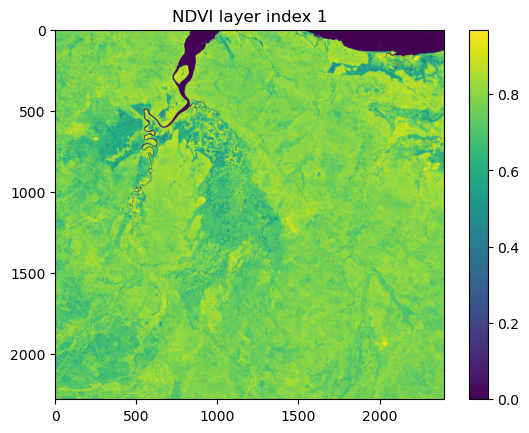

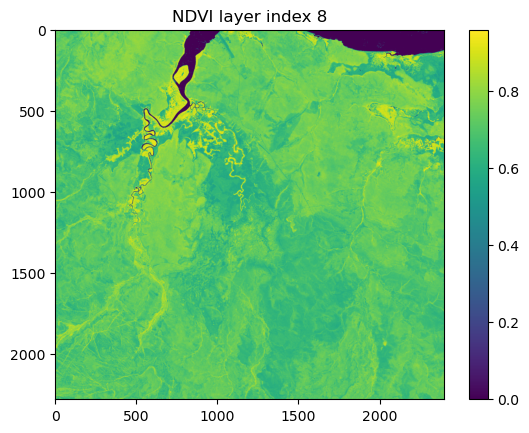

In [41]:
# Check the coordinate reference system
print("NDVI metadata:")
print(ndvi_meta)
print("\n")

# Have a look at the affine transformation parameters that are used to convert pixel 
# coordinates to geographic coordinates and vice versa
print("Affine transformation parameters:")
print(raster_transform)
print("\n")

# Check the shape (layers, row, columns) of the raster
print("Shape of the raster:")
print(ndvi_landscape.shape)

# Check for NA values in the ndvi raster:
print("Number of NA values in the ndvi raster:")
print(np.isnan(ndvi_landscape).sum())

# Replace NaNs in the original array with -1, which represents water
ndvi_landscape = np.nan_to_num(ndvi_landscape, nan=-1.0)

# Check for NA values in the ndvi raster:
print("Number of NA values in the ndvi raster after setting to -1:")
print(np.isnan(ndvi_landscape).sum())

# from the stack of local layers (training data)
ndvi_min = np.min(ndvi_landscape)
ndvi_max = np.max(ndvi_landscape)
print(f'Minimum NDVI value: {ndvi_min}')
print(f'Maximum NDVI value: {ndvi_max}')

# Normalizing the data
ndvi_landscape_norm = (ndvi_landscape - ndvi_min) / (ndvi_max - ndvi_min)

# Show two example layers of the scaled NDVI data
layer_index = 1
plt.imshow(ndvi_landscape_norm[layer_index,:,:])
plt.colorbar()  
plt.title(f'NDVI layer index {layer_index}')
plt.show()

layer_index = 8
plt.imshow(ndvi_landscape_norm[layer_index,:,:])
plt.colorbar()  
plt.title(f'NDVI layer index {layer_index}')
plt.show()

In [42]:
print(ndvi_landscape.shape)

(24, 2280, 2400)


## Canopy cover

Canopy cover is just a single static layer.

In [43]:
# Path to the canopy cover raster file
file_path = '../mapping/cropped rasters/canopy_cover.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    canopy_landscape = src.read(1)
    # Get the metadata of the raster
    canopy_meta = src.meta

### Prepare the canopy cover data

As with the NDVI data, we need to ensure that there are no NA values in the data. 

As the canopy cover values in the landscape layer are within the same range as the training data, we see that the values range from 0 to 1.

Canopy metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of canopy raster:
(2280, 2400)


Number of NA values in the canopy raster:
0
Mini

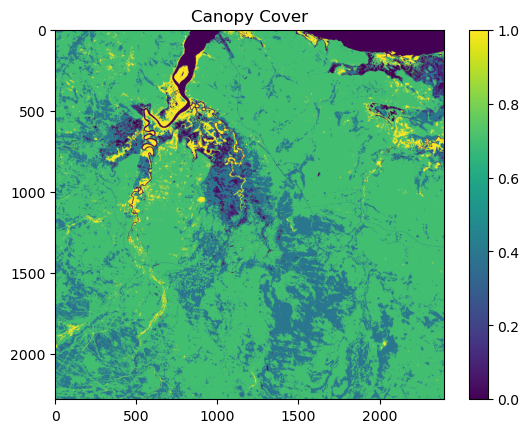

In [44]:
# Check the canopy metadata:
print("Canopy metadata:")
print(canopy_meta)
print("\n")

# Check the shape (rows, columns) of the canopy raster:
print("Shape of canopy raster:")
print(canopy_landscape.shape)
print("\n")

# Check for NA values in the canopy raster:
print("Number of NA values in the canopy raster:")
print(np.isnan(canopy_landscape).sum())

# Define the maximum and minimum canopy values from the stack of local layers:
canopy_min = np.min(canopy_landscape)
canopy_max = np.max(canopy_landscape)
print(f'Minimum canopy value: {canopy_min}')
print(f'Maximum canopy value: {canopy_max}')

# Normalise the canopy data:
canopy_landscape_norm = (canopy_landscape - canopy_min) / (canopy_max - canopy_min)

# Visualise the normalised canopy cover:
plt.imshow(canopy_landscape_norm)
plt.colorbar()
plt.title('Canopy Cover')
plt.show()


## Herbaceous vegetation

In [45]:
# Path to the herbaceous vegetation raster file
file_path = '../mapping/cropped rasters/veg_herby.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    herby_landscape = src.read(1)
    # Get the metadata of the raster
    herby_meta = src.meta

Herbaceous metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of herbaceous raster:
(2280, 2400)


Number of NA values in the herbaceous ve

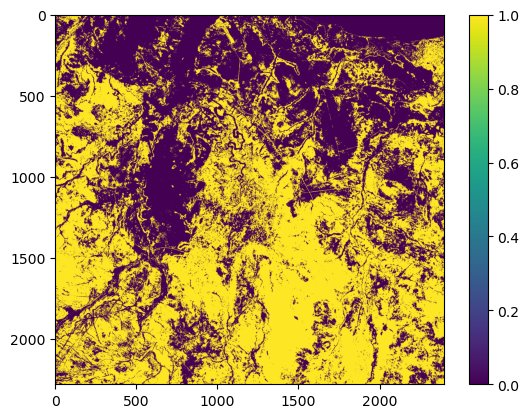

In [46]:
# Check the herbaceous metadata:
print("Herbaceous metadata:")
print(herby_meta)
print("\n")

# Check the shape (rows, columns) of the herbaceous raster:
print("Shape of herbaceous raster:")
print(herby_landscape.shape)
print("\n")

# Check for NA values in the herby raster:
print("Number of NA values in the herbaceous vegetation raster:")
print(np.isnan(herby_landscape).sum())

# Define the maximum and minimum herbaceous values from the stack of local layers:
herby_min = np.min(herby_landscape)
herby_max = np.max(herby_landscape)
print(f'Minimum herbaceous value: {herby_min}')
print(f'Maximum herbaceous value: {herby_max}')

# Normalize the herbaceous data:
herby_landscape_norm = (herby_landscape - herby_min) / (herby_max - herby_min)

# Visualize the normalised herbaceous cover:
plt.imshow(herby_landscape_norm)
plt.colorbar()
plt.show()


## Slope

In [47]:
# Path to the slope raster file
file_path = '../mapping/cropped rasters/slope.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    slope_landscape = src.read(1)
    # Get the metadata of the raster
    slope_meta = src.meta

Slope metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of slope landscape raster:
(2280, 2400)


Number of NA values in the slope raster:
9356
Minimum slope 

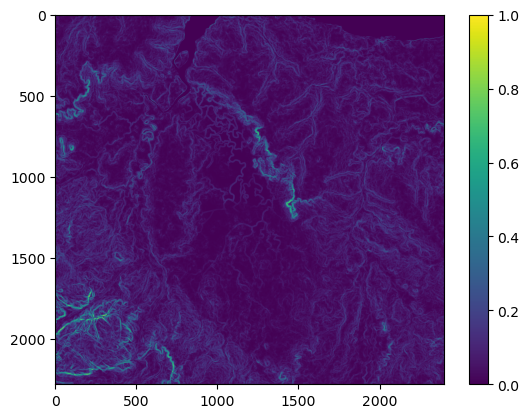

In [48]:
# Check the slope metadata:
print("Slope metadata:")
print(slope_meta)
print("\n")

# Check the shape (rows, columns) of the slope landscape raster:
print("Shape of slope landscape raster:")
print(slope_landscape.shape)
print("\n")

# Check for NA values in the slope raster:
print("Number of NA values in the slope raster:")
print(np.isnan(slope_landscape).sum())

# Replace NaNs in the slope array with 0.0:
slope_landscape = np.nan_to_num(slope_landscape, nan=0.0)

# Define the maximum and minimum slope values from the stack of local layers:
slope_min = np.min(slope_landscape)
slope_max = np.max(slope_landscape)
print(f'Minimum slope value: {slope_min}')
print(f'Maximum slope value: {slope_max}')

# Normalize the slope landscape data:
slope_landscape_norm = (slope_landscape - slope_min) / (slope_max - slope_min)

# Visualize the slope landscape (note: displaying the original tensor, not the normalised data):
plt.imshow(slope_landscape_norm)
plt.colorbar()
plt.show()


### Convert between numpy array and raster

To check that we can go back and forth between numpy arrays (with pixel coordinates) and rasters (with geographic coordinates), we will convert the slope numpy array to a raster. 

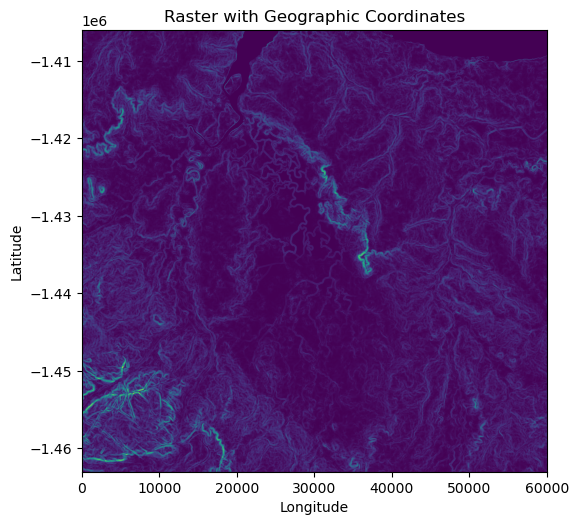

In [49]:
# Create a figure and axis with matplotlib
fig, ax = plt.subplots(figsize=(6, 6))

# Convert the slope_landcape (numpy array) to a raster and plot with the rasterio library
rasterio.plot.show(slope_landscape, transform=raster_transform, ax=ax, cmap='viridis')

# Set the title and labels
ax.set_title('Raster with Geographic Coordinates')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the plot
plt.show()

# Subset function (with padding)

Now that we have our landscape layers imported, we need a way to crop out the local layers that can be saved for training the deepSSF model.

We will use the same subset function as in the deepSSF simulation notebook, which we stored in the `deepSSF_utils.py` script. This function will take the landscape layers and a set of coordinates, and return the local layers for those coordinates.

This function also has padding for if the simulated individual was to go off the edge of the landscape, which we retain here (although we should not need that functionality).

In [50]:
subset_raster = deepSSF_utils.subset_raster_with_padding_npy
subset_raster

<function deepSSF_utils.subset_raster_with_padding_npy(raster_npy, x, y, window_size, transform)>

### Testing the subset function

Use the subset function to crop out the local layers for all covariates. Try different locations using the x and y coordinates, which are in geographic coordinates (x = easting/longitude, y = northing/latitude).

Buffalo location: 41921.52193883266, -1435654.2946495365
NDVI index: 6
Distance between locations: -142.082344736511, 53.568427147110924
x1 pixel coordinates: 1676.8608775533064, 1186.1717859814598
x1 pixel coordinates (floored): 1676, 1186
Target pixel coordinates: 1671.1775837638459, 1184.0290488955798
Target pixel coordinates (floored): 1671, 1184
Distance between pixels: -5, -2
Target pixel using origin: 45, 48
Target pixel using distance in pixel coords: 45, 48


Text(0.5, 1.0, 'Slope Subset')

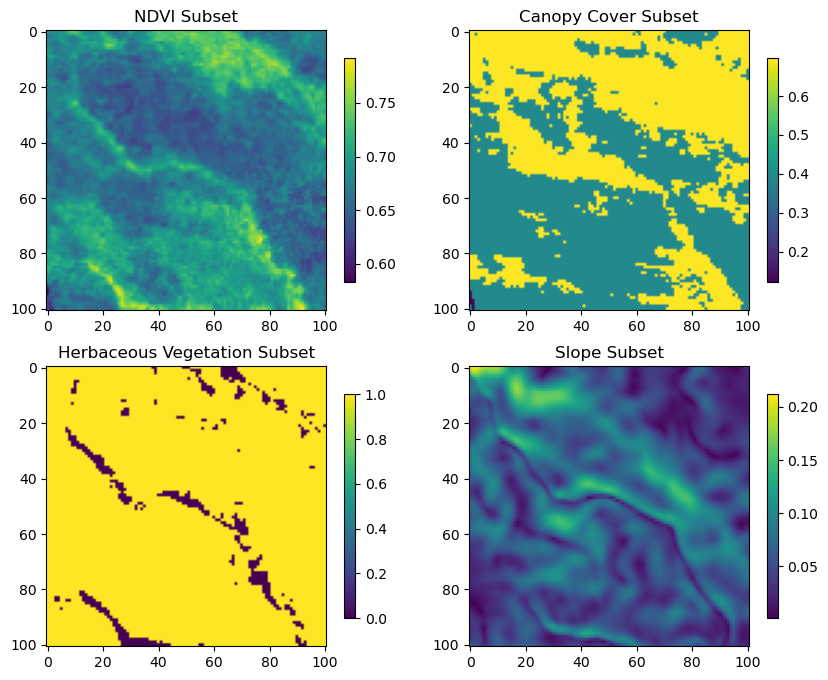

In [51]:
location_index = 1

# Pick a location (x, y) from the buffalo DataFrame
x = buffalo_df['x1_'].iloc[location_index]
y = buffalo_df['y1_'].iloc[location_index]

print(f'Buffalo location: {x}, {y}')

# Define the size of the window to extract
window_size = 101  

# Select the NDVI layer index that corresponds to the time of the buffalo location
# Find index of minimum absolute difference
ndvi_index = np.argmin(np.abs(ndvi_datetime_values - buffalo_df['t1_int'].iloc[location_index]))
print(f'NDVI index: {ndvi_index}') 


# Extract subsets from various raster layers using the custom function.
# Each call centres the window at the specified (x, y) location and applies padding where necessary.

# NDVI subset
ndvi_subset, origin_x, origin_y = subset_raster(ndvi_landscape_norm[ndvi_index, :, :], 
                                                x, y, window_size, raster_transform)

# Canopy Cover subset
canopy_subset, origin_x, origin_y = subset_raster(canopy_landscape_norm, 
                                                  x, y, window_size, raster_transform)

# Herbaceous Vegetation subset
herby_subset, origin_x, origin_y = subset_raster(herby_landscape_norm, 
                                                 x, y, window_size, raster_transform)

# Slope subset
slope_subset, origin_x, origin_y = subset_raster(slope_landscape_norm, 
                                                 x, y, window_size, raster_transform)

# Target (also as a numpy array)
x2 = buffalo_df['x2_'].iloc[location_index]
y2 = buffalo_df['y2_'].iloc[location_index]

dx = x2 - x
dy = y2 - y
print(f'Distance between locations: {dx}, {dy}')

# Convert geographic coordinates to pixel coordinates using the inverse transform.
# The raster transform is defined when reading the raster file.

# print(f'Origin x and y: {origin_x}, {origin_y}')

px1, py1 = ~raster_transform * (x, y)
print(f'x1 pixel coordinates: {px1}, {py1}')
# Round the pixel coordinates to the nearest integers.
px1, py1 = int(np.floor(px1)), int(np.floor(py1))
print(f'x1 pixel coordinates (floored): {px1}, {py1}')

target_px, target_py = ~raster_transform * (x2, y2)
print(f'Target pixel coordinates: {target_px}, {target_py}')

# Round the pixel coordinates to the nearest integers.
target_px, target_py = int(np.floor(target_px)), int(np.floor(target_py))
print(f'Target pixel coordinates (floored): {target_px}, {target_py}')

# Calculate the distance between the origin and target pixel coordinates.
dx = target_px - px1
dy = target_py - py1
print(f'Distance between pixels: {dx}, {dy}')

print(f'Target pixel using origin: {target_px - origin_x}, {target_py - origin_y}')

print(f'Target pixel using distance in pixel coords: {50+dx}, {50+dy}')

# Create a 2x2 grid of subplots with a fixed figure size.
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plot the NDVI subset
im0 = axs[0, 0].imshow(ndvi_subset, cmap='viridis')
fig.colorbar(im0, ax=axs[0, 0], shrink=0.8)
axs[0, 0].set_title('NDVI Subset')

# Plot the Canopy Cover subset
im1 = axs[0, 1].imshow(canopy_subset, cmap='viridis')
fig.colorbar(im1, ax=axs[0, 1], shrink=0.8)
axs[0, 1].set_title('Canopy Cover Subset')

# Plot the Herbaceous Vegetation subset
im2 = axs[1, 0].imshow(herby_subset, cmap='viridis')
fig.colorbar(im2, ax=axs[1, 0], shrink=0.8)
axs[1, 0].set_title('Herbaceous Vegetation Subset')

# Plot the Slope subset
im3 = axs[1, 1].imshow(slope_subset, cmap='viridis')
fig.colorbar(im3, ax=axs[1, 1], shrink=0.8)
axs[1, 1].set_title('Slope Subset')

# Loop over all steps and save the local layers



## Create a directory to save the local layers

As some cloud storage systems (e.g. OneDrive) do not work well with many individual files (e.g. 100,000s of local layers), we will save the local layers on the hard drive, near the root of the C drive. We will create a directory to save the local layers in.

In [52]:
local_root_dir = '/Users/scottforrest/deepSSF' # add the r before the string to avoid escape characters
os.makedirs(local_root_dir, exist_ok=True)

# Create directories for the different covariates
local_ndvi_dir = os.path.join(local_root_dir, 'ndvi')
local_canopy_dir = os.path.join(local_root_dir, 'canopy')
local_herby_dir = os.path.join(local_root_dir, 'herby')
local_slope_dir = os.path.join(local_root_dir, 'slope') 
local_target_dir = os.path.join(local_root_dir, 'target')

# Create the directories
os.makedirs(local_ndvi_dir, exist_ok=True)
os.makedirs(local_canopy_dir, exist_ok=True)    
os.makedirs(local_herby_dir, exist_ok=True)
os.makedirs(local_slope_dir, exist_ok=True)
os.makedirs(local_target_dir, exist_ok=True)

## Check the number of steps in the trajectory

In [53]:
len(buffalo_df)

103558

Total number of steps: 103558
[--------------------] 0%

Buffalo ID: 2005
Step date: 2018-07-25
Step hour: 11.07
NDVI index: 6
x1 pixel coordinates (floored):     1678, 1186
Target pixel coordinates (floored): 1676, 1186
x1 pixel indices:                   50, 50
Target pixel indices:               48, 50


[--------------------] 0%

Buffalo ID: 2005
Step date: 2018-07-25
Step hour: 12.07
NDVI index: 6
x1 pixel coordinates (floored):     1676, 1186
Target pixel coordinates (floored): 1671, 1184
x1 pixel indices:                   50, 50
Target pixel indices:               45, 48


[--------------------] 0%

Buffalo ID: 2005
Step date: 2018-07-25
Step hour: 13.07
NDVI index: 6
x1 pixel coordinates (floored):     1671, 1184
Target pixel coordinates (floored): 1673, 1185
x1 pixel indices:                   50, 50
Target pixel indices:               52, 51


[--------------------] 0%

Buffalo ID: 2005
Step date: 2018-07-25
Step hour: 14.07
NDVI index: 6
x1 pixel coordinates (floored):     

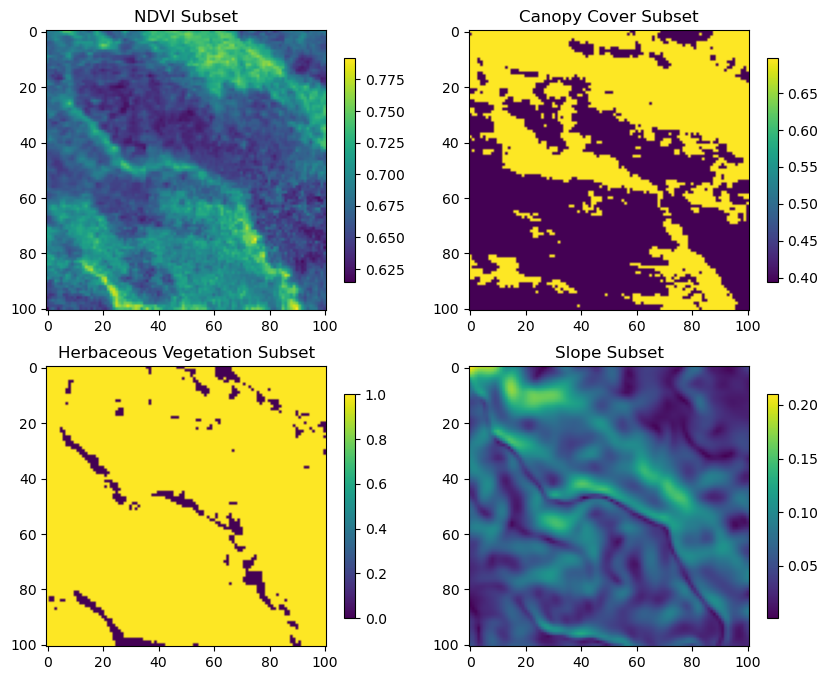

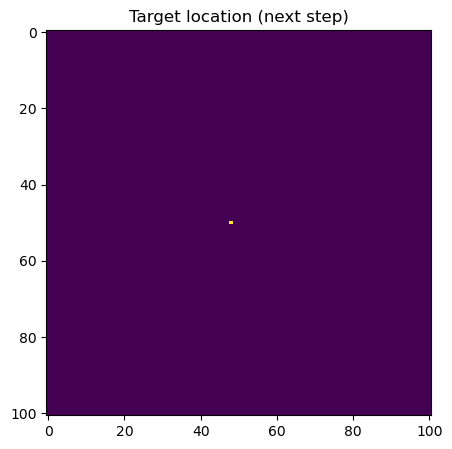

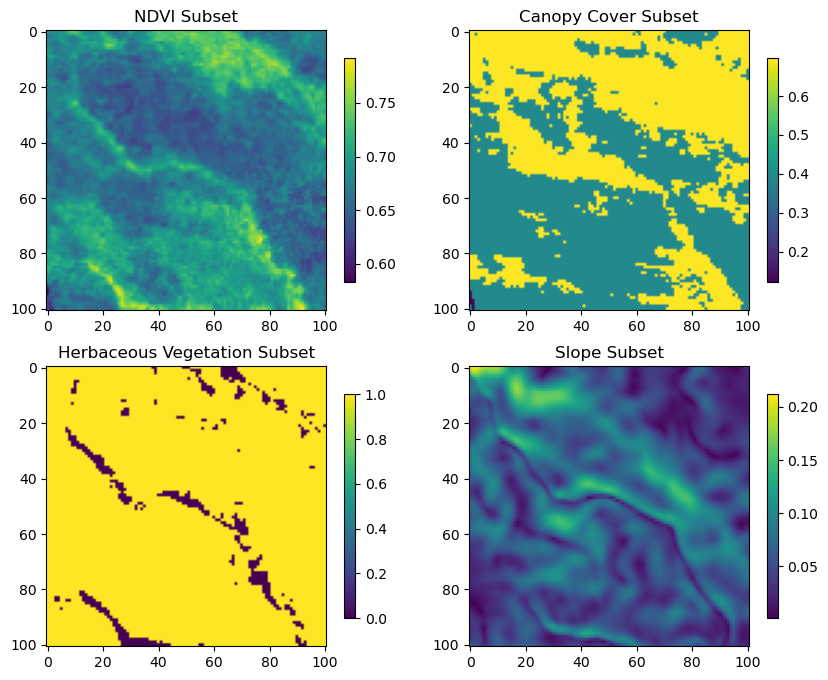

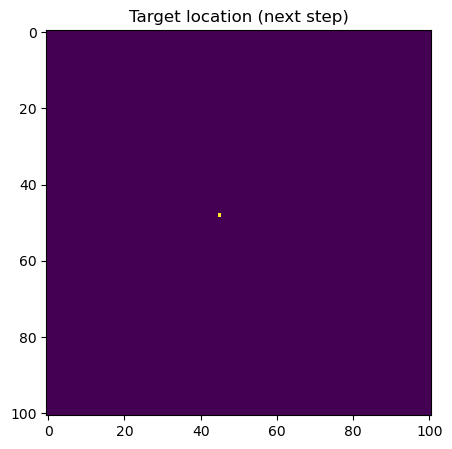

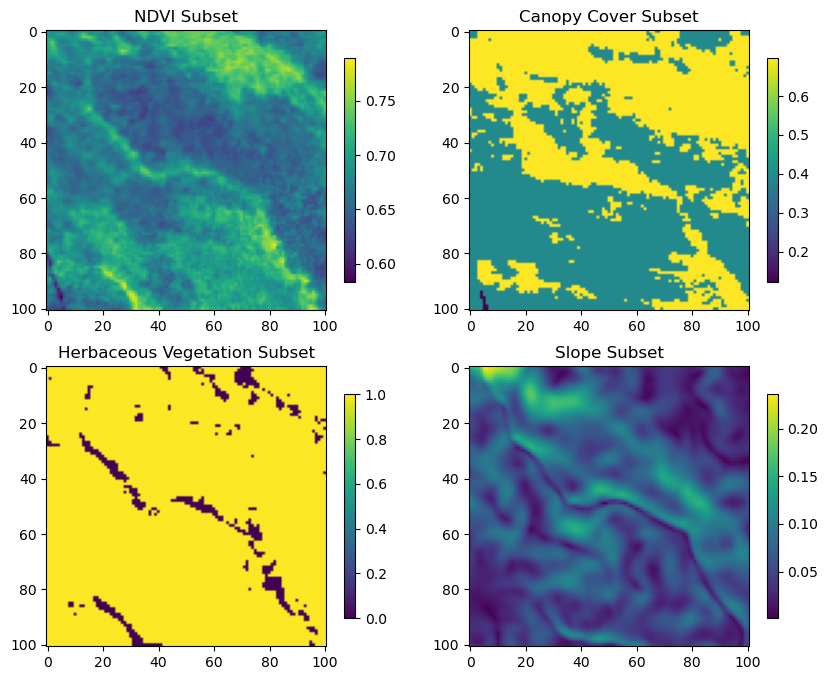

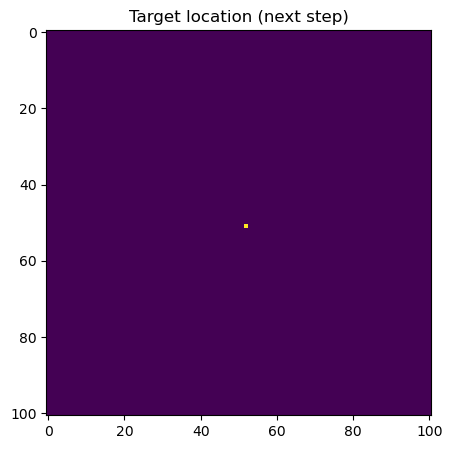

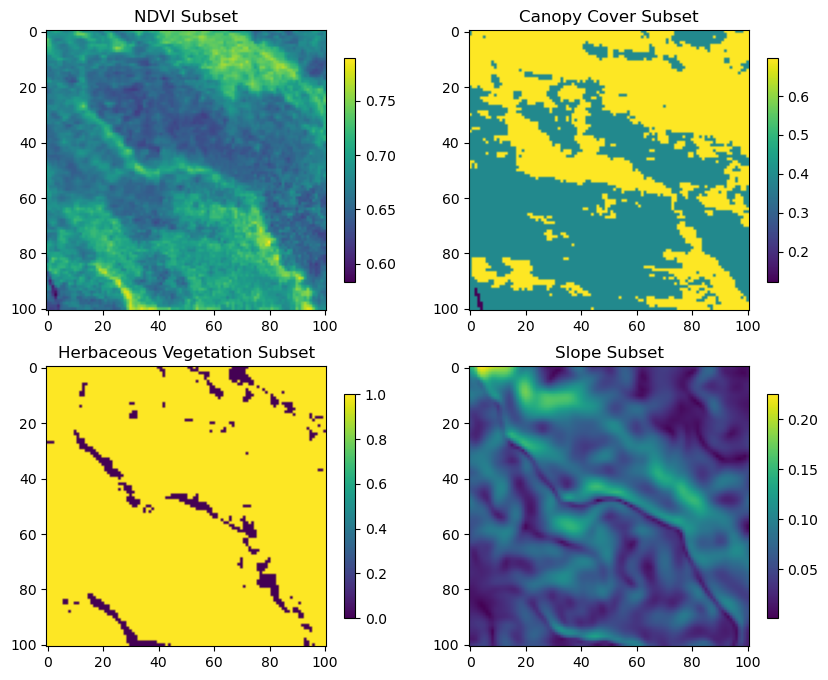

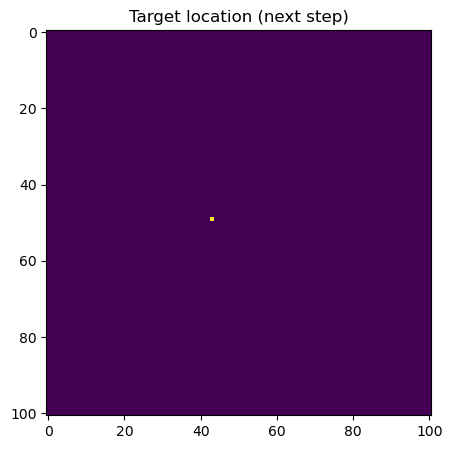

In [61]:
total_steps = len(buffalo_df)
print(f'Total number of steps: {total_steps}')

# total_steps = 1000

for location_index in range(total_steps): 
# for location_index in range(10): # for testing

    # Extract some info for saving the data
    buffalo_id = buffalo_df['id'].iloc[location_index]
    step_date = buffalo_df['t1_'].iloc[location_index].strftime('%Y-%m-%d')
    step_hour = buffalo_df['hour_t1'].iloc[location_index]

    # Pick a location (x, y) from the buffalo DataFrame
    x = buffalo_df['x1_'].iloc[location_index]
    y = buffalo_df['y1_'].iloc[location_index]
    # print(f'Buffalo location: {x}, {y}')
    # Check that the current location is in the central cell of the local layers
    px1, py1 = ~raster_transform * (x, y)
    # Floor the pixel coordinates to get the pixel indices
    px1, py1 = int(np.floor(px1)), int(np.floor(py1))

    # Define the size of the window to extract
    window_size = 101  

    # Select the NDVI layer index that corresponds to the time of the buffalo location
    # Find index of minimum absolute difference
    ndvi_index = np.argmin(np.abs(ndvi_datetime_values - buffalo_df['t1_int'].iloc[location_index]))


    # Extract subsets from various raster layers using the custom function.
    # Each call centres the window at the specified (x, y) location and applies padding where necessary.

    # NDVI subset
    ndvi_subset, origin_x, origin_y = subset_raster(ndvi_landscape_norm[ndvi_index, :, :], 
                                                    x, y, window_size, raster_transform)

    # Canopy Cover subset
    canopy_subset, origin_x, origin_y = subset_raster(canopy_landscape_norm, 
                                                    x, y, window_size, raster_transform)

    # Herbaceous Vegetation subset
    herby_subset, origin_x, origin_y = subset_raster(herby_landscape_norm, 
                                                    x, y, window_size, raster_transform)

    # Slope subset
    slope_subset, origin_x, origin_y = subset_raster(slope_landscape_norm, 
                                                    x, y, window_size, raster_transform)
    
    # Save the subset as npy files
    ndvi_file_path = os.path.join(local_root_dir, f'ndvi/ndvi_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    np.save(ndvi_file_path, ndvi_subset)

    canopy_file_path = os.path.join(local_root_dir, f'canopy/cnpy_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    np.save(canopy_file_path, canopy_subset)

    herby_file_path = os.path.join(local_root_dir, f'herby/herb_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    np.save(herby_file_path, herby_subset)

    slope_file_path = os.path.join(local_root_dir, f'slope/slop_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    np.save(slope_file_path, slope_subset)
    
    # Target (also as a numpy array)
    x2 = buffalo_df['x2_'].iloc[location_index]
    y2 = buffalo_df['y2_'].iloc[location_index]

    px2, py2 = ~raster_transform * (x2, y2)
    # print(f'Target pixel coordinates: {px2}, {py2}')
    # Floor the pixel coordinates to get the pixel indices
    px2, py2 = int(np.floor(px2)), int(np.floor(py2))
    next_step_x2 = px2 - origin_x
    next_step_y2 = py2 - origin_y

    # Create a square array of zeros with the given dimension
    target = np.zeros_like(ndvi_subset)
    target[next_step_y2, next_step_x2] = 1 # row, column

    # Save the target as an npy file
    target_file_path = os.path.join(local_root_dir, f'target/targ_id{buffalo_id}_t1_{step_date}_hour{step_hour}.npy')
    np.save(target_file_path, target)

    # Update the csv file with the file paths
    buffalo_df.loc[location_index, 'ndvi_path'] = ndvi_file_path
    buffalo_df.loc[location_index, 'canopy_path'] = canopy_file_path
    buffalo_df.loc[location_index, 'herby_path'] = herby_file_path
    buffalo_df.loc[location_index, 'slope_path'] = slope_file_path
    buffalo_df.loc[location_index, 'target_path'] = target_file_path

    # Progress bar
    # Calculate the percentage completed
    progress = location_index / total_steps
    # Create a simple bar representation (20 characters wide)
    bar_length = 20
    filled_length = int(bar_length * progress)
    bar = '#' * filled_length + '-' * (bar_length - filled_length)
    # Calculate the percentage as an integer
    percent = int(100 * progress)
    # Print the progress bar (overwrite the same line with \r)
    print(f'\r[{bar}] {percent}%', end='')

    # -------------------------------------------------------------------------
    # Plot some of the local rasters
    # -------------------------------------------------------------------------

    # Plot the first few probability surfaces
    if location_index < 4:

        print('\n')

        print(f'Buffalo ID: {buffalo_id}')
        print(f'Step date: {step_date}')
        print(f'Step hour: {step_hour}')
        print(f'NDVI index: {ndvi_index}')
        print(f'x1 pixel coordinates (floored):     {px1}, {py1}')
        print(f'Target pixel coordinates (floored): {px2}, {py2}')
        print(f'x1 pixel indices:                   {px1 - origin_x}, {py1 - origin_y}')
        print(f'Target pixel indices:               {next_step_x2}, {next_step_y2}')
    
        print('\n')

        # Create a 2x2 grid of subplots with a fixed figure size.
        fig, axs = plt.subplots(2, 2, figsize=(10, 8))

        # Plot the NDVI subset
        im0 = axs[0, 0].imshow(ndvi_subset, cmap='viridis')
        fig.colorbar(im0, ax=axs[0, 0], shrink=0.8)
        axs[0, 0].set_title('NDVI Subset')

        # Plot the Canopy Cover subset
        im1 = axs[0, 1].imshow(canopy_subset, cmap='viridis')
        fig.colorbar(im1, ax=axs[0, 1], shrink=0.8)
        axs[0, 1].set_title('Canopy Cover Subset')

        # Plot the Herbaceous Vegetation subset
        im2 = axs[1, 0].imshow(herby_subset, cmap='viridis')
        fig.colorbar(im2, ax=axs[1, 0], shrink=0.8)
        axs[1, 0].set_title('Herbaceous Vegetation Subset')

        # Plot the Slope subset
        im3 = axs[1, 1].imshow(slope_subset, cmap='viridis')
        fig.colorbar(im3, ax=axs[1, 1], shrink=0.8)
        axs[1, 1].set_title('Slope Subset')

        # Also plot the target as a single plot
        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(target, cmap='viridis')
        ax.set_title('Target location (next step)')
        
# Save the updated DataFrame to a new CSV file
buffalo_df.to_csv(f'{local_root_dir}/buffalo_all_steps_with_paths_n{total_steps}_steps.csv', index=False)

In [60]:
print(target.shape)

(101, 101)
